# HW1 Zhenyang Cui

- What: Download, manipulate and merge two or more datasets
- How: Create functions in a python file (src/Zhenyang_Cui/...)
- Show: Show how to use these python files in a notebook

# 1. Research Question

- How does the elasticity of consumption with respect to different types of household wealth differ?
- Specifically, what are the differences in elasticity between housing wealth and stock market wealth in Japan?

# 2. Method

## 2.1 Data Sources

- **Consumption**: Household consumption expenditure (from Family Income and Expenditure Survey - 家計調査)
- **Housing Wealth**: Fixed assets (housing component) from National Accounts (SNA)
- **Stock Market Wealth**: Household financial assets (specifically "stocks") from National Accounts (SNA)
- **Income**: Compensation of employees from National Accounts (SNA)

# 2.2 Empirical Strategy

- Convert all series to:
  - **Real terms** (adjusted for inflation)
  - **Per capita** (divided by total population)

- Conduct a regression based on the following model:

$$
\log C_{t} = \alpha + \beta \log S_{t} + \gamma \log H_{t} + \phi \log Y_{t} + \epsilon_{t}
$$

- Where:

\begin{array}{ll}
C_{t} & : \text{Household consumption} \\
S_{t} & : \text{Stock market wealth} \\
H_{t} & : \text{Housing wealth} \\
Y_{t} & : \text{Compensation of employees}
\end{array}


## 2.3 Main Focus

- Estimate and compare:

\begin{array}{ll}
\gamma & : \text{Elasticity of consumption with respect to housing wealth} \\
\beta & : \text{Elasticity of consumption with respect to stock market wealth}
\end{array}


# 3. Goal

- Understand the relative importance of housing and stock market wealth in driving household consumption behavior in Japan.


# 4.1 Download data

- Download household consumption data.

In [4]:
import os
import requests

# Create directory if not exists
os.makedirs("data/raw data/japan", exist_ok=True)

# Download URL
url = "https://www.esri.cao.go.jp/jp/sna/data/data_list/kakuhou/files/2023/tables/2023ffm1n_jp.xlsx"

# File path to save
save_path = "data/raw data/japan/household_consumption.xlsx"

# Download the file
response = requests.get(url)
with open(save_path, 'wb') as f:
    f.write(response.content)

print("Download completed and saved as 'household_consumption.xlsx'.")


Download completed and saved as 'household_consumption.xlsx'.


- Download stock market wealth data.
- Download houseing wealth data.

In [5]:
import os
import requests

# Create directory if not exists
os.makedirs("data/raw data/japan", exist_ok=True)

# Download URL
url = "https://www.esri.cao.go.jp/jp/sna/data/data_list/kakuhou/files/2023/tables/2023si4_jp.xlsx"

# File path to save
save_path = "data/raw data/japan/household_stock.xlsx"

# Download the file
response = requests.get(url)
with open(save_path, 'wb') as f:
    f.write(response.content)

print("Download completed and saved as 'household_stock.xlsx'.")


Download completed and saved as 'household_stock.xlsx'.


- Download income data (compensation of employees).

In [6]:
import os
import pandas as pd
import requests

# Create directory if not exists
os.makedirs("data/raw data/japan", exist_ok=True)

# Download file
url = "https://www.esri.cao.go.jp/jp/sna/data/data_list/kakuhou/files/2023/tables/2023ffm2_jp.xlsx"
save_path = "data/raw data/japan/employment_income.xlsx"

# Download using requests
response = requests.get(url)
with open(save_path, 'wb') as f:
    f.write(response.content)

# Now read the downloaded file
df = pd.read_excel(save_path)

# Save it again if needed
df.to_excel(save_path, index=False)

print("Employment income data downloaded and saved!")

Employment income data downloaded and saved!


## 4.2 Manipulate Data

- Manipulate household consumption data.

In [7]:
import os
import sys

# Move working directory to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), "/Users/Jared/Documents/GitHub/graspp_2025_spring")) ###**************************
os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")

# Add 'src' to sys.path
sys.path.append("src")
from data_function.extract_household_consumption import extract_household_consumption

# Extract data
save_path = "notebooks/assignment_individual/HW1/data/raw data/japan/household_consumption.xlsx"
consumption_data = extract_household_consumption(save_path)

# Save processed data
processed_dir = "notebooks/assignment_individual/HW1/data/processing_data/japan/"
os.makedirs(processed_dir, exist_ok=True)

processed_path = os.path.join(processed_dir, "processed_household_consumption.csv")
consumption_data.to_csv(processed_path, index=False)

print(f"Processed data saved to: {processed_path}")


Working directory set to: /Users/Jared/Documents/GitHub/graspp_2025_spring
Processed data saved to: notebooks/assignment_individual/HW1/data/processing_data/japan/processed_household_consumption.csv


- Manipulate
  - stock market wealth data.
  - houseing wealth data.

In [8]:
import os
import sys

# Move working directory to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), "/Users/Jared/Documents/GitHub/graspp_2025_spring")) ###**************************
os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")

# Add 'src' to sys.path
sys.path.append("src")
from data_function.extract_housing_and_stock import extract_housing_and_stock

# Extract data
file_path = "notebooks/assignment_individual/HW1/data/raw data/japan/household_stock.xlsx"
processed_data = extract_housing_and_stock(file_path)

# Create directory if not exists
processed_dir = "notebooks/assignment_individual/HW1/data/processing_data/japan/"
os.makedirs(processed_dir, exist_ok=True)

# Save as CSV
processed_path = os.path.join(processed_dir, "processed_household_stock.csv")
processed_data.to_csv(processed_path, index=False)

print("Processed data saved as CSV!")

Working directory set to: /Users/Jared/Documents/GitHub/graspp_2025_spring
Processed data saved as CSV!


- Manipulate income data (compensation of employees).

In [9]:
import os
import sys

# Move working directory to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), "/Users/Jared/Documents/GitHub/graspp_2025_spring")) ###**************************
os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")

# Add 'src' to sys.path
sys.path.append("src")
from data_function.extract_employment_income import extract_employment_income

# Create directory if not exists
processed_dir = "notebooks/assignment_individual/HW1/data/processing_data/japan/"
os.makedirs(processed_dir, exist_ok=True)

# Extract data
file_path = "notebooks/assignment_individual/HW1/data/raw data/japan/employment_income.xlsx"
processed_employment_income = extract_employment_income(file_path)

# Save as CSV
processed_path = os.path.join(processed_dir, "processed_employment_income.csv")
processed_employment_income.to_csv(processed_path, index=False)

print("Processed employment income data saved as CSV!")

Working directory set to: /Users/Jared/Documents/GitHub/graspp_2025_spring
Processed employment income data saved as CSV!


## 4.3 Merge Data

In [10]:
import pandas as pd
import os

# Define file paths
raw_path = "/Users/Jared/Documents/GitHub/graspp_2025_spring/notebooks/assignment_individual/HW1/data/processing_data/japan/"  # Processed CSV files folder　###**************************
clean_path = "/Users/Jared/Documents/GitHub/graspp_2025_spring/notebooks/assignment_individual/HW1/data/clean/"           # Save merged data here

csv_files = {
    "household_consumption": os.path.join(raw_path, "processed_household_consumption.csv"),
    "housing_stock_wealth": os.path.join(raw_path, "processed_household_stock.csv"),
    "employee_income": os.path.join(raw_path, "processed_employment_income.csv"),
}

# Read each dataset
consumption = pd.read_csv(csv_files["household_consumption"])
housing_stock = pd.read_csv(csv_files["housing_stock_wealth"])
employee_income = pd.read_csv(csv_files["employee_income"])

# Merge on 'year'
merged_data = consumption.merge(
    housing_stock, on="year", how="inner"
).merge(
    employee_income, on="year", how="inner"
)

# Check the merged dataset
print(merged_data.head())

# Confirm columns
print(merged_data.columns)

# Round
value_columns = ['household_consumption', 'fixed_asset', 'stock_asset', 'employment_income']
merged_data[value_columns] = merged_data[value_columns].round(0).astype(int)


# Create the clean directory if not exists
os.makedirs(clean_path, exist_ok=True)

# Save
merged_data.to_csv(os.path.join(clean_path, "merged_macro_data.csv"), index=False)

print("Merged dataset saved successfully!")


   year  household_consumption  fixed_asset  stock_asset  employment_income
0  1994               266250.9     397066.4     130971.4           262822.6
1  1995               271381.7     399831.5     128776.7           267095.2
2  1996               278702.4     416861.5     118755.9           272962.4
3  1997               279745.5     423410.6      86465.8           279054.2
4  1998               278920.2     418589.8      80110.8           273370.2
Index(['year', 'household_consumption', 'fixed_asset', 'stock_asset',
       'employment_income'],
      dtype='object')
Merged dataset saved successfully!


## 5. Descriptive Statistics

In [11]:
# Import
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load merged data
merged_data = pd.read_csv("/Users/Jared/Documents/GitHub/graspp_2025_spring/notebooks/assignment_individual/HW1/data/clean/merged_macro_data.csv")


# Show descriptive statistics
print("Descriptive Statistics (Original Data):")
print(merged_data.describe())

# Convert values to billion yen (divide by 1000)
value_columns = ['household_consumption', 'fixed_asset', 'stock_asset', 'employment_income']
merged_data[value_columns] = merged_data[value_columns] / 1000

# Show descriptive statistics again after conversion
print("\nDescriptive Statistics (Converted to Billion Yen):")
print(merged_data.describe())


Descriptive Statistics (Original Data):
              year  household_consumption    fixed_asset   stock_asset  \
count    30.000000              30.000000      30.000000      30.00000   
mean   2008.500000          286519.100000  410729.966667  143437.70000   
std       8.803408            9773.603498   13696.322105   48360.75906   
min    1994.000000          266251.000000  385535.000000   80111.00000   
25%    2001.250000          280426.750000  401289.750000  102274.25000   
50%    2008.500000          283809.500000  409338.000000  134562.50000   
75%    2015.750000          291108.250000  418097.250000  178615.50000   
max    2023.000000          314756.000000  443824.000000  250212.00000   

       employment_income  
count          30.000000  
mean       268422.100000  
std         13729.709079  
min        251155.000000  
25%        257151.000000  
50%        266433.500000  
75%        273625.000000  
max        302364.000000  

Descriptive Statistics (Converted to Billion Yen)

## 6. Visualization

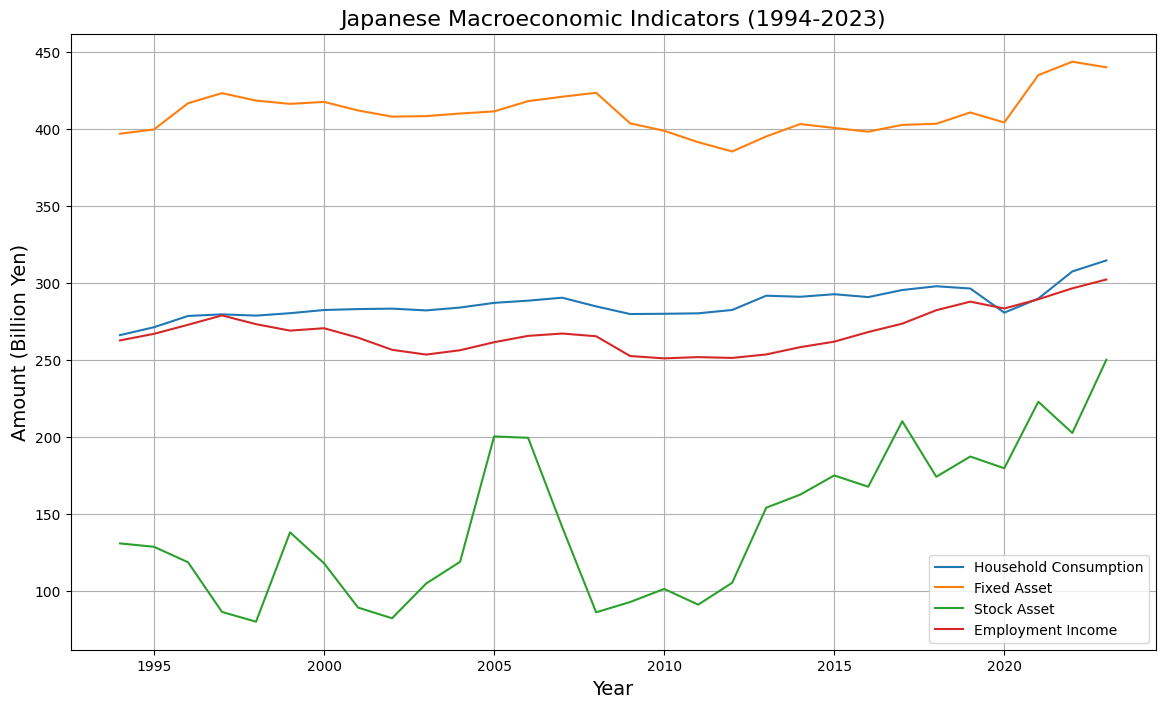

In [12]:
# Plotting
plt.figure(figsize=(14, 8))

# Plot each variable
for column in value_columns:
    plt.plot(merged_data['year'], merged_data[column], label=column.replace('_', ' ').title())

# Title and labels
plt.title("Japanese Macroeconomic Indicators (1994-2023)", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Amount (Billion Yen)", fontsize=14)
plt.legend()
plt.grid(True)

# Save the figure if needed
# plt.savefig("macro_data_trends.png", dpi=300)

plt.show()


## 7. Regression

### 7.1 Modeling

 - Make values become log-transformed variables.

In [13]:
import numpy as np 

# Create log-transformed variables
merged_data["log_household_consumption"] = np.log(merged_data["household_consumption"])
merged_data["log_fixed_asset"] = np.log(merged_data["fixed_asset"])
merged_data["log_stock_asset"] = np.log(merged_data["stock_asset"])
merged_data["log_employment_income"] = np.log(merged_data["employment_income"])

# Check
print(merged_data[["log_household_consumption", "log_fixed_asset", "log_stock_asset", "log_employment_income"]].head())


   log_household_consumption  log_fixed_asset  log_stock_asset  \
0                   5.584439         5.984103         4.874976   
1                   5.603527         5.991044         4.858082   
2                   5.630143         6.032755         4.777071   
3                   5.633882         6.048343         4.459751   
4                   5.630925         6.036892         4.383413   

   log_employment_income  
0               5.571481  
1               5.587604  
2               5.609333  
3               5.631405  
4               5.610826  


#### 7.1.1 OLS

In [14]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Assuming 'data' is your DataFrame
# Prepare independent variables
X = merged_data[["log_fixed_asset", "log_stock_asset", "log_employment_income"]]
X = sm.add_constant(X)  # Adds a constant term (intercept)

# Prepare dependent variable
y = merged_data["log_household_consumption"]

# Run OLS regression
model = sm.OLS(y, X).fit()

# Show results
print(model.summary())


                                OLS Regression Results                               
Dep. Variable:     log_household_consumption   R-squared:                       0.524
Model:                                   OLS   Adj. R-squared:                  0.469
Method:                        Least Squares   F-statistic:                     9.536
Date:                       Tue, 29 Apr 2025   Prob (F-statistic):           0.000202
Time:                               16:13:51   Log-Likelihood:                 70.763
No. Observations:                         30   AIC:                            -133.5
Df Residuals:                             26   BIC:                            -127.9
Df Model:                                  3                                         
Covariance Type:                   nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

### → Findings from the Results

### Coefficient Interpretations

- **`log_stock_asset` (Stock Market Wealth)**
  - **Coefficient (β) = 0.0560**, **p-value = 0.003** → **Statistically significant at the 1% level**.
  - → **An increase in stock market wealth is strongly associated with higher household consumption**.

- **`log_fixed_asset` (presumably Housing Wealth)**
  - **Coefficient (γ) = 0.2938**, **p-value = 0.163** → **Not statistically significant (even at the 10% level)**.
  - → **The relationship between housing wealth and consumption appears weak and statistically insignificant**.

- **`log_employment_income` (Compensation of Employees)**
  - **Coefficient = 0.0207**, **p-value = 0.897** → **Highly insignificant**.
  - → **No detectable effect of employment income on consumption in this model**.

### Model Fit

- **R-squared = 0.524** → **Moderate explanatory power** (the model explains about 52% of the variation in household consumption).

### Cautions

- The **Condition Number is large (1850)**, which suggests **potential multicollinearity**.

---

### Summary (in brief)
- **Stock market wealth has a small but statistically significant positive effect on consumption.**
- **Housing wealth shows a larger coefficient but is not statistically significant.**
- **Employment income appears irrelevant for consumption dynamics in this model.**
- **Maybe multicollinearity issues occurs.**


#### 7.1.1 VIF

In [15]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = merged_data[["log_fixed_asset", "log_stock_asset", "log_employment_income"]]

# Caculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

import ace_tools as tools; tools.display_dataframe_to_user(name="VIF Calculation Results", dataframe=vif_data)

vif_data


ModuleNotFoundError: No module named 'ace_tools'

#### 7.1.1 OLS